# KMeans Clustering on MNIST dataset

### Objective

The objective of this experiment is to apply the **K-Means clustering algorithm** on the **MNIST handwritten digit dataset**.

### Tasks Performed
- Load the MNIST dataset.
- Flatten 28×28 images into feature vectors.
- Apply K-Means clustering.
- Compare clusters with the true digit labels.
- Estimate clustering accuracy.
- Visualize cluster centroids.
- Interpret the clustering results.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
from scipy.stats import mode                 #statistical mode function

## Loading the MNIST Dataset

The MNIST dataset contains grayscale images of handwritten digits.

- Training Images: **60,000**
- Testing Images: **10,000**
- Image Size: **28 × 28 pixels**
- Classes: **10 (Digits 0–9)**

Since K-Means works with feature vectors, each image is flattened into a **784-dimensional vector**.

In [14]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

In [16]:
train_df.shape

(42000, 785)

In [17]:
train_df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [19]:
test_df.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [37]:
# Split training data into images and labels
y_train = train_df["label"]
X_train = train_df.drop("label", axis=1)

# Test data has no labels
X_test = test_df

In [38]:
print("Training Images:", X_train.shape)
print("Training Labels:", y_train.shape)
print("Testing Images:", X_test.shape)

Training Images: (42000, 784)
Training Labels: (42000,)
Testing Images: (28000, 784)


### Flatten Images

Since we loaded the MNIST data from a `CSV file`, it is already flattened.

## Visualizing Sample Images

The following images are randomly selected samples from the MNIST dataset.

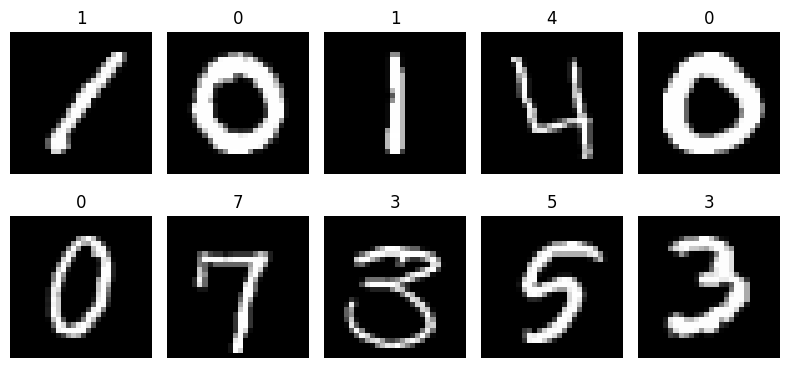

In [39]:
fig, axes = plt.subplots(2,5, figsize=(8,4))

for i, ax in enumerate(axes.flat):
    image = X_train.iloc[i].values.reshape(28, 28)  # convert 784 → 28x28 ,to make it an image with pixel values
    
    ax.imshow(image, cmap="gray")
    ax.set_title(y_train.iloc[i]) # Adds the correct digit above the image
    ax.axis("off") # Turns off the x-axis and y-axis markings

plt.tight_layout() # Automatically adjusts spacing between plots.Without it, titles and images may overlap.
plt.show()

## Applying K-Means Clustering

The algorithm groups the images into **10 clusters**, corresponding to the ten handwritten digits.

The cluster assignments are determined by minimizing the Euclidean distance between each image and its nearest centroid.

In [40]:
kmeans = KMeans(
    n_clusters=10,    # 10 clusters
    random_state=42,
    n_init=10)

clusters = kmeans.fit_predict(X_train)

**Purpose of n_init:**

K-Means starts with random cluster centers. It will run the algorithm 10 times with different initial centers and keep the solution with the lowest within-cluster variance (inertia). This generally produces a better result than relying on a single random initialization.

## Mapping Clusters to Digit Labels

Since K-Means is an unsupervised algorithm, it produces cluster IDs instead of digit labels.

Each cluster is assigned the digit that appears most frequently within it. This mapping is then used to estimate clustering accuracy.

K-Means does not know that a cluster represents a particular digit, so you first need to map each cluster to the most common actual label.

In [41]:
predicted_labels = np.zeros_like(clusters) # Creates an array of zeros with the same shape as clusters

for i in range(10):       # Since MNIST has 10 possible digits, K-Means created 10 clusters
    mask = clusters == i  # Find which images belong to this cluster
    predicted_labels[mask] = mode(y_train[mask], keepdims=True).mode[0] # Find the most common true label in that cluster

accuracy = accuracy_score(y_train, predicted_labels)

print(f"Estimated Clustering Accuracy: {accuracy*100:.2f}%")

Estimated Clustering Accuracy: 59.10%


This is actually a reasonable accuracy for K-Means on MNIST.

59.10% means K-Means found meaningful digit-like groups, even though it was never told what a "7" or "3" looks like.

## Cluster Visualization

The centroid of each cluster represents the average handwritten digit learned by the K-Means algorithm.

These centroid images help visualize the characteristics of each cluster.

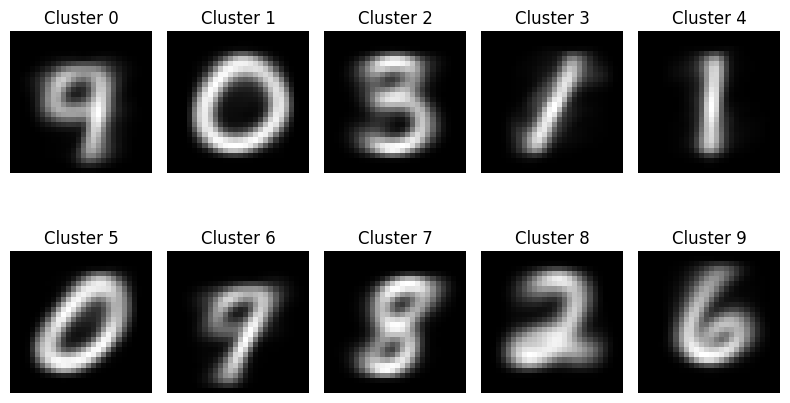

In [42]:
fig, axes = plt.subplots(2,5, figsize=(8,5))

for i, ax in enumerate(axes.flat):
    ax.imshow(kmeans.cluster_centers_[i].reshape(28,28),
              cmap="gray")
    ax.set_title(f"Cluster {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()

**why are there two 0s and two 1s?**

We might think:

"There are 10 clusters and 10 digits. Why didn't it make exactly one cluster per digit?"

* Because K-Means does not know digits exist.
* It only sees pixel patterns.
* For example, the two "0" clusters might represent different writing styles

## Interpretation of Results

- Most clusters capture the general shape of a handwritten digit.
- Some clusters contain multiple digits because different handwritten digits can have similar visual patterns.
- Digits such as **3 and 5**, **4 and 9**, or **8 and 9** may overlap in the feature space.
- Since K-Means relies only on feature similarity and does not use labels during training, perfect clustering accuracy is not expected.

# Conclusion

- Successfully loaded the MNIST dataset.
- Converted images into 784-dimensional feature vectors.
- Applied the K-Means clustering algorithm.
- Assigned clusters and mapped them to the most frequent true labels.
- Estimated clustering accuracy.
- Visualized cluster centroids and interpreted the resulting clusters.

K-Means effectively groups visually similar handwritten digits, demonstrating the application of unsupervised learning to image data.